In [1]:
# Basic python libraries
import os
import time
import joblib
import pandas as pd
import numpy as np

# Visualizarition libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn and other ml functions
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, accuracy_score, f1_score, roc_auc_score, make_scorer

In [2]:
# Only for colab
#from google.colab import drive
#drive.mount('/content/drive')

#from google.colab import userdata

# Evaluación de modelos benchmark

En este capítulo se evualúan diferentes modelos de machine learning y deep learning que nos permitan identificar arritmias cardiacas, acorde con el problema propuesto.

Para esto


In [3]:
# Only for colab
# Read the data
#train_path = userdata.get('mitbih_train')
#df_train = pd.read_csv(train_path, header=None)

#test_path = userdata.get('mitbih_test')
#df_test = pd.read_csv(test_path, header=None)

In [4]:
# Read the data

train_path = "../../proyecto/data/mitbih_train.csv"
df_train = pd.read_csv(train_path, header=None)

test_path = "../../proyecto/data/mitbih_test.csv"
df_test = pd.read_csv(test_path, header=None)

In [5]:
# Set the train an test arrays
X_train,y_train = df_train.iloc[:,:-1], df_train.iloc[:,-1]
X_test, y_test = df_test.iloc[:,:-1], df_test.iloc[:,-1]

## Balanceo de clases



SMOTE (Synthetic Minority Over-sampling Technique), ADASYN (Adaptive Synthetic Sampling), class_weight='balanced' de Scikit-learn.

## Benchmark de modelos

En esta capítulo de presenta el benchmark de los siguientes modelos:


- KNN
- Clasificación de Bayes
- Regresión Logística (Regularización L1/L2)
- Decision Tree
- Random Forest
- XGBoost (Lime)
- SVM
- MLP
- RNN
- LSTM
- CNN
- Autoencoders


Además, se utilizarán los siguientes algotirmos de ?????


- KNN → KD-Trees, Ball Trees, FAISS.
- Naive Bayes → partial_fit() para entrenamiento por lotes.
- **XGBoost** → tree_method='hist' y early_stopping_rounds.
- SVM → SGD SVM (SGDClassifier) , 
- LinearSVC en vez de SVC(kernel='linear'), 
- RBF con Random Fourier Features





Finalmente, como método de evaluación se utilizará el Recall, como un medida de confiabilidad para la presentación de resultados



Matrices de confusión, curvas ROC, Tabla de métricas de precisión, con las siguientes columnas. Explicar que métrica de validación fue seleccionada y por qué (why recall?)

### Configuración de la ejecución

In [6]:
scorer = "recall_macro" # Definimos el recall como métrica para cross validation en grid search
n_jobs = -2 # Usamos todos menos uno de los cores de la CPU
refit = True # Reentrenamos el modelo con el mejor conjunto de hiperparámetros
verbose = 1 # Mostramos el progreso de la búsqueda de hiperparámetros
cv = 5 # Usamos 5 folds para la validación cruzada
random_state=42 # Semilla para la aleatoriedad

In [7]:
def evaluate_and_save_model(grid_search_fitted, model_name, X_test, y_test, training_time):
    """
    Evaluates the best estimator from a grid search fitted model and saves evaluation results.

    Parameters:
    - grid_search_fitted (GridSearchCV): Fitted GridSearchCV object containing the best estimator.
    - model_name (str): Name of the model for saving results.
    - X_test (array-like of shape (n_samples, n_features)): Test data features.
    - y_test (array-like of shape (n_samples,)): True labels for test data.
    - training_time (float): Time taken to train the model.

    Returns:
    - None: Saves evaluation results and best estimator model to files.

    Notes:
    - Results are saved as pickle files: {model_name}_results.pkl and best_{model_name}_model.pkl
    - Evaluation metrics include precision, recall, accuracy, F1 score, confusion matrix, ROC AUC score, and classification report.
    """

    # Obtain best estimator from grid search
    best_estimator = grid_search_fitted.best_estimator_

    # Predict with test data
    y_pred = best_estimator.predict(X_test)
    y_pred_proba = best_estimator.predict_proba(X_test)

    # Calculate evaluation metrics
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr') if hasattr(best_estimator, 'predict_proba') else np.nan
    report = classification_report(y_test, y_pred)

    # Save evaluation results
    results = {
        'precision_test': precision,
        'recall_test': recall,
        'accuracy_test': accuracy,
        'f1_score_test': f1,
        'confusion_matrix': cm,
        'y_pred_prob': y_pred_proba,
        'auc_test': auc,
        'classification_report': report,
        'cpu_time': training_time,
        'best_params': grid_search_fitted.best_params_,
        'best_recall_cv': grid_search_fitted.best_score_,
        'cv_results': grid_search_fitted.cv_results_
    }

    # Save results and best model
    joblib.dump(results, f"results/{model_name}_results.pkl")
    joblib.dump(best_estimator, f"models/best_{model_name}_model.pkl")
    print(f"Modelo y resultados guardados exitosamente en 'models/best_{model_name}_model.pkl' y 'results/{model_name}_results.pkl'.")

### KNN

In [8]:
# Libraries for knn
from sklearn.neighbors import KNeighborsClassifier

#### Definir los hiperparámetos

In [9]:
knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7],
    'algorithm': ['ball_tree', 'kd_tree', 'faiss']
}

#### Grid search para entrenar el mejor estimador

In [10]:
knn = KNeighborsClassifier()
start_time = time.time()
knn_grid_search = GridSearchCV(knn, knn_param_grid, scoring=scorer, cv=cv, verbose=verbose, n_jobs=n_jobs, refit=refit)
knn_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\base.py", line 666, in _validate_params
    val

#### Guardamos los resultados

In [11]:
model_name = "knn" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(knn_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_knn_model.pkl' y 'results/knn_results.pkl'.


#### Análisis de resultados generales y test

In [12]:
knn_results = joblib.load("results/knn_results.pkl")

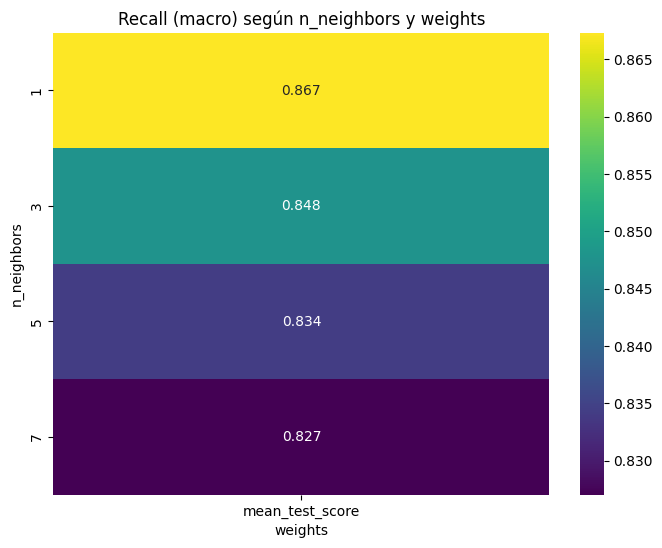

In [13]:
cv_results_df = pd.DataFrame(knn_results['cv_results'])

pivot = cv_results_df.pivot_table(index='param_n_neighbors',
                                  #columns='param_weights',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según n_neighbors y weights")
plt.xlabel("weights")
plt.ylabel("n_neighbors")
plt.show()

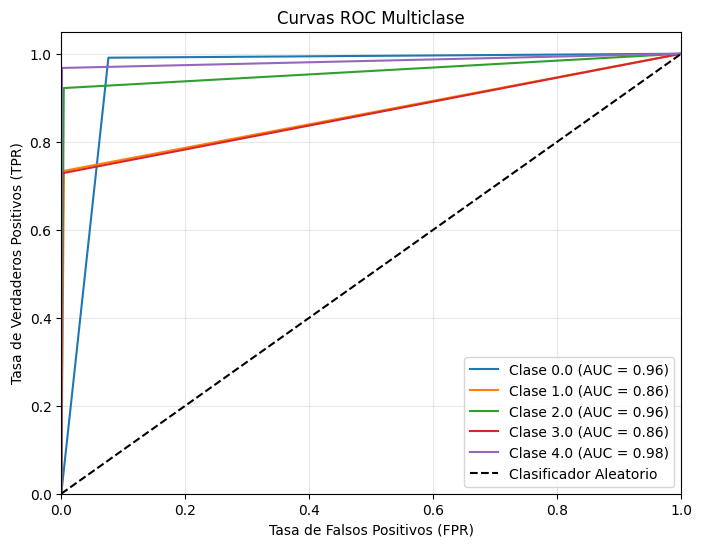

In [14]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = knn_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

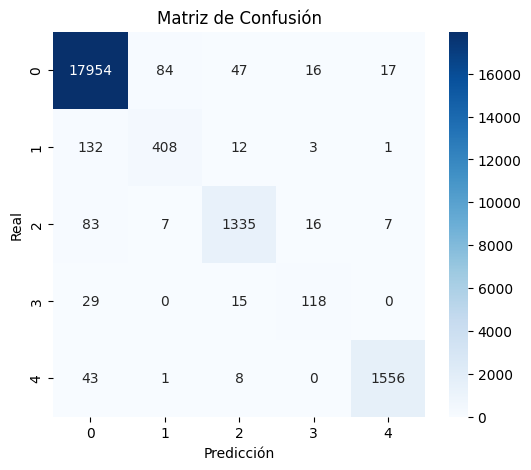

In [15]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(knn_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")    
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [16]:
print("Reporte de Clasificación:\n", knn_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     18118
         1.0       0.82      0.73      0.77       556
         2.0       0.94      0.92      0.93      1448
         3.0       0.77      0.73      0.75       162
         4.0       0.98      0.97      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.87      0.88     21892
weighted avg       0.98      0.98      0.98     21892



In [17]:
pd.DataFrame(knn_results["cv_results"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,4.854034,0.602060,867.799731,6.329146,ball_tree,1,"{'algorithm': 'ball_tree', 'n_neighbors': 1}",0.864455,0.874834,0.871268,0.864194,0.861808,0.867312,0.004907,1
1,5.787230,0.318221,916.147086,12.684448,ball_tree,3,"{'algorithm': 'ball_tree', 'n_neighbors': 3}",0.842500,0.845430,0.853307,0.847991,0.849012,0.847648,0.003617,3
2,5.932471,0.280649,877.648901,38.148830,ball_tree,5,"{'algorithm': 'ball_tree', 'n_neighbors': 5}",0.828991,0.833246,0.842461,0.837188,0.829176,0.834212,0.005108,5
3,6.167510,0.203123,868.646685,12.200763,ball_tree,7,"{'algorithm': 'ball_tree', 'n_neighbors': 7}",0.819866,0.825346,0.832518,0.830804,0.826584,0.827024,0.004444,7
4,6.567450,0.124597,140.527117,4.662762,kd_tree,1,"{'algorithm': 'kd_tree', 'n_neighbors': 1}",0.864455,0.874834,0.871268,0.864194,0.861808,0.867312,0.004907,1
5,6.503462,0.196072,184.166617,10.873656,kd_tree,3,"{'algorithm': 'kd_tree', 'n_neighbors': 3}",0.842500,0.845430,0.853307,0.847991,0.849012,0.847648,0.003617,3
6,6.330136,0.170726,173.438915,5.996783,kd_tree,5,"{'algorithm': 'kd_tree', 'n_neighbors': 5}",0.828991,0.833246,0.842461,0.837188,0.829176,0.834212,0.005108,5
7,5.628980,0.177416,162.514831,6.304179,kd_tree,7,"{'algorithm': 'kd_tree', 'n_neighbors': 7}",0.819866,0.825346,0.832518,0.830804,0.826584,0.827024,0.004444,7
8,0.119329,0.006090,0.000000,0.000000,faiss,1,"{'algorithm': 'faiss', 'n_neighbors': 1}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
9,0.121814,0.015251,0.000000,0.000000,faiss,3,"{'algorithm': 'faiss', 'n_neighbors': 3}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,9


### Decision Tree

In [18]:
# libraries for decision trees
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

#### Definir los hiperparámetos

In [19]:
# Set the hyperparameters

tree_param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy'],
}


#### Grid search para entrenar el mejor estimador

In [20]:
tree = DecisionTreeClassifier(random_state=random_state)
start_time = time.time()
tree_grid_search = GridSearchCV(tree, tree_param_grid, scoring=scorer, cv=cv, verbose=verbose, n_jobs=n_jobs, refit=refit)
tree_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 12 candidates, totalling 60 fits


#### Guardamos los resultados

In [21]:
model_name = "tree" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(tree_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_tree_model.pkl' y 'results/tree_results.pkl'.


#### Análisis de resultados generales y test

In [56]:
tree_results = joblib.load("results/tree_results.pkl")

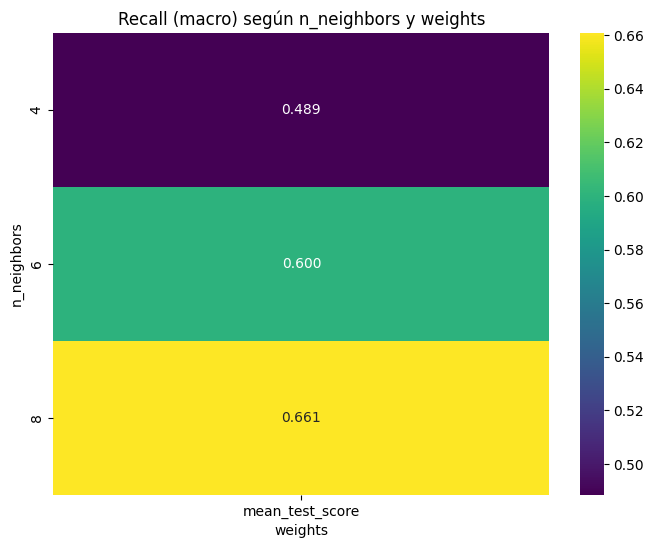

In [58]:
cv_results_df = pd.DataFrame(tree_results['cv_results'])

pivot = cv_results_df.pivot_table(index='param_max_depth', 
                                  #columns='param_weights', 
                                  values='mean_test_score')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro) según n_neighbors y weights")
plt.xlabel("weights")
plt.ylabel("n_neighbors")
plt.show()

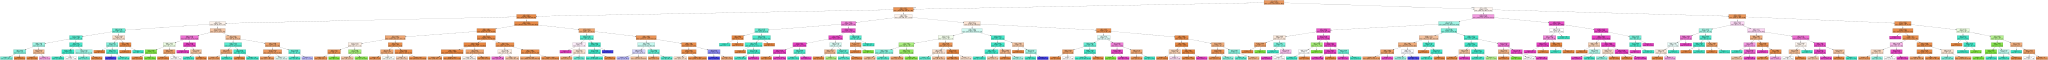

In [65]:
# Plot the tree
export_graphviz(tree_grid_search.best_estimator_,
                out_file="results/tree.dot",
                impurity=False,
                filled=True)

with open("results/tree.dot") as f:
    dot_graph = f.read()
    graph = graphviz.Source(dot_graph)

graphviz.Source(dot_graph)

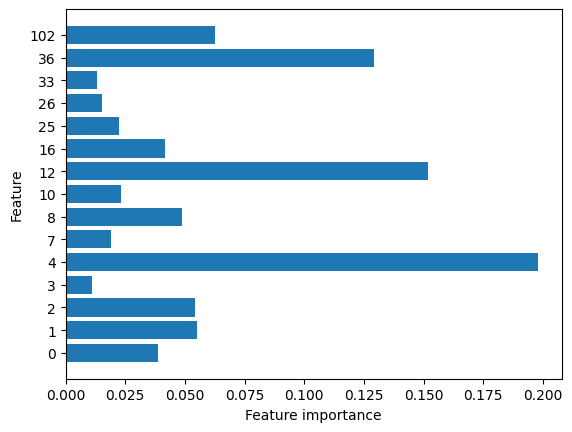

In [73]:
importances = tree_grid_search.best_estimator_.feature_importances_
mask = importances > 0.01
filtered_importances = importances[mask]
filtered_features = X_train.columns[mask].astype(str)

plt.barh(np.arange(len(filtered_importances)), filtered_importances, align='center')
plt.yticks(np.arange(len(filtered_importances)), filtered_features)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

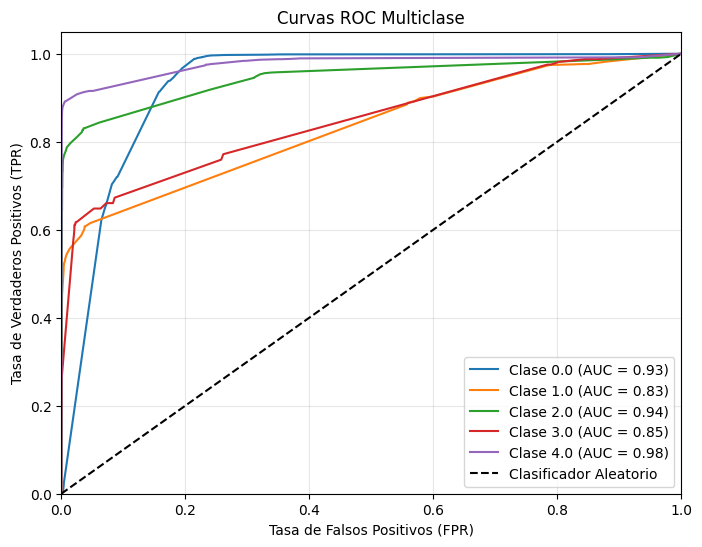

In [61]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = tree_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

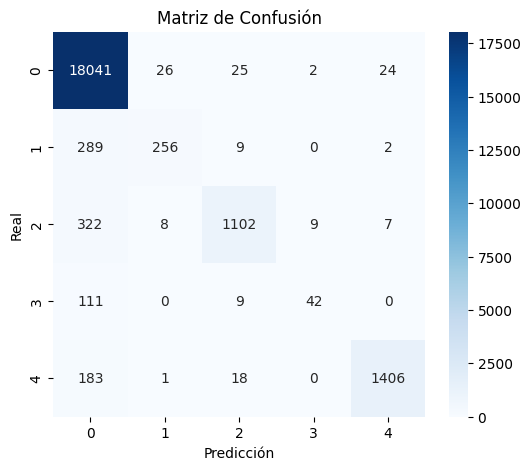

In [62]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(tree_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")    
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [ ]:
print("Reporte de Clasificación:\n", tree_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     18118
         1.0       0.82      0.73      0.77       556
         2.0       0.94      0.92      0.93      1448
         3.0       0.77      0.73      0.75       162
         4.0       0.98      0.97      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.87      0.88     21892
weighted avg       0.98      0.98      0.98     21892



In [64]:
pd.DataFrame(tree_results["cv_results"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,5.864887,0.188926,0.027067,0.002394,4,{'max_depth': 4},0.491118,0.490629,0.488003,0.484815,0.488078,0.488529,0.002253,3
1,8.777209,0.105486,0.026877,0.001897,6,{'max_depth': 6},0.595223,0.591816,0.596712,0.619213,0.594812,0.599555,0.009956,2
2,9.940058,0.646965,0.028353,0.015473,8,{'max_depth': 8},0.654160,0.669396,0.645731,0.668477,0.666730,0.660899,0.009371,1


### Logistic Regresión


In [22]:
from sklearn.linear_model import LogisticRegression

#### Definir los hiperparámetos

In [23]:
logreg_param_grid = {
    'penalty': ['l1', 'l2', 'none'],
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'saga']
}

#### Grid search para entrenar el mejor estimador

In [24]:
logreg_clf = LogisticRegression(random_state=random_state)
start_time = time.time()
logreg_grid_search = GridSearchCV(
    logreg_clf,
    param_grid=logreg_param_grid, scoring=scorer, cv=cv, verbose=verbose, n_jobs=n_jobs, refit=refit)
logreg_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
30 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\luisl\anaconda3\envs\practical-exam\lib\site-packages\sklearn\base.py", line 666, in _validate_params
    vali

#### Guardamos los resultados

In [25]:
model_name = "reglog" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(logreg_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_reglog_model.pkl' y 'results/reglog_results.pkl'.


#### Análisis de resultados generales y test

In [137]:
logreg_results = joblib.load("results/reglog_results.pkl")

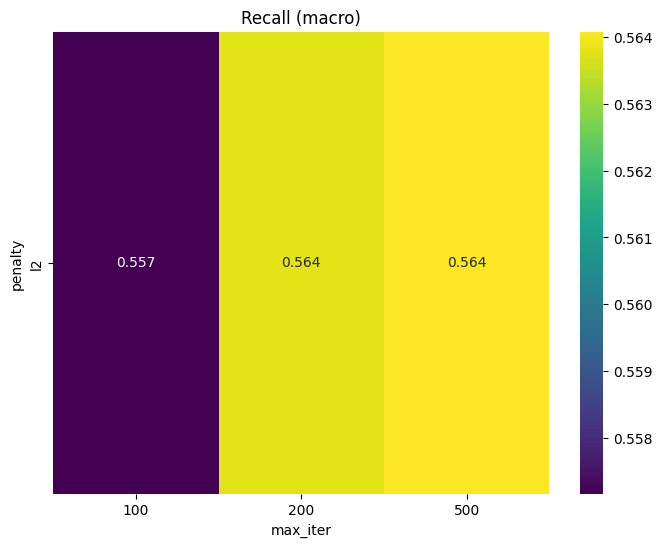

In [139]:
cv_results_df = pd.DataFrame(logreg_results['cv_results'])

pivot = cv_results_df.pivot_table(index='param_penalty',
                                  columns='param_max_iter',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro)")
plt.xlabel("max_iter")
plt.ylabel("penalty")
plt.show()

### Random Forest


In [26]:
from sklearn.ensemble import RandomForestClassifier

#### Definir los hiperparámetos

In [27]:
rf_param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

In [28]:
rf = RandomForestClassifier(random_state=42)
start_time = time.time()
rf_grid_search = GridSearchCV(rf, rf_param_grid, scoring=scorer, cv=cv, verbose=verbose, n_jobs=n_jobs, refit=refit)
rf_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 27 candidates, totalling 135 fits


#### Guardamos los resultados

In [29]:
model_name = "rf" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(rf_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_rf_model.pkl' y 'results/rf_results.pkl'.


#### Análisis de resultados generales y test

In [77]:
rf_results = joblib.load("results/rf_results.pkl")

### XGBoost

In [8]:
import xgboost as xgb

In [9]:
xgb_param_grid = {
    'tree_method': ['hist', 'approx'],
    'learning_rate': [0.01, 0.1, 0.2],
    #'early_stopping_rounds': [10, 20],
    'max_depth': [3, 6], 
    'n_estimators': [100,200,400]
}

#### Grid search para entrenar el mejor estimador

In [ ]:
xgb_model = xgb.XGBClassifier(device='cuda:0', verbosity=2)
start_time = time.time()
xgb_grid_search = GridSearchCV(
    xgb_model,
    param_grid=xgb_param_grid,
    scoring=scorer,
    cv=cv,
    verbose=verbose,
    n_jobs=n_jobs,
    refit=refit
)
xgb_grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

Fitting 5 folds for each of 36 candidates, totalling 180 fits


#### Guardamos los resultados

In [ ]:
model_name = "xgb" # Cambiar el nombre del modelo

#-----------------#
evaluate_and_save_model(xgb_grid_search, model_name, X_test, y_test, training_time)

Modelo y resultados guardados exitosamente en 'models/best_xgb_model.pkl' y 'results/xgb_results.pkl'.


#### Análisis de resultados generales y test

In [115]:
xgb_results = joblib.load("results/xgb_results.pkl")

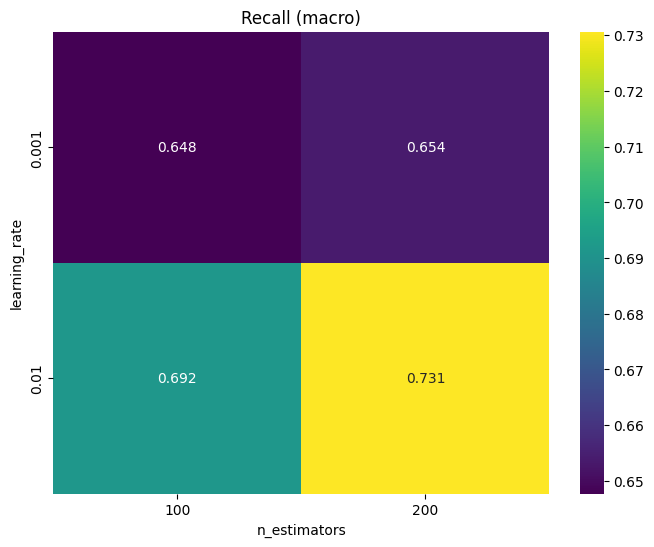

In [122]:
cv_results_df = pd.DataFrame(xgb_results['cv_results'])

pivot = cv_results_df.pivot_table(index='param_learning_rate',
                                  columns='param_n_estimators',
                                  values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall (macro)")
plt.xlabel("n_estimators")
plt.ylabel("learning_rate")
plt.show()

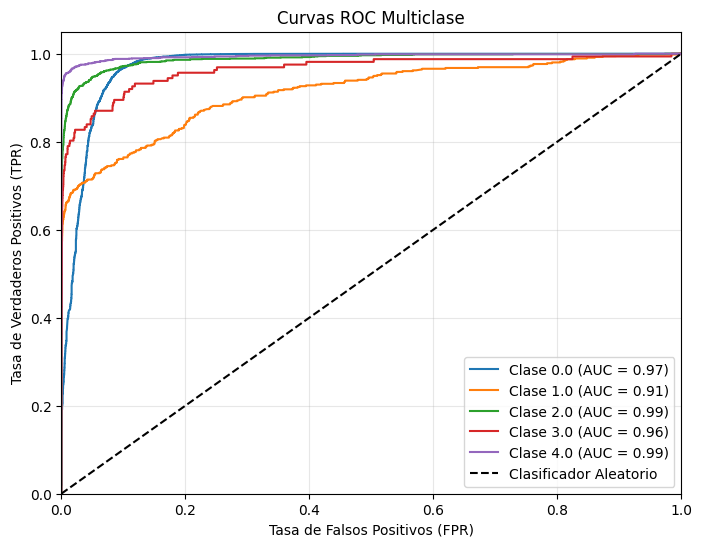

In [117]:
from sklearn.metrics import roc_curve, auc # Dejarlo aquí

y_pred_proba = xgb_results['y_pred_prob']

# Binarización de las clases
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Inicialización de diccionarios para almacenar métricas
fpr, tpr, roc_auc = {}, {}, {}

# Cálculo de las curvas ROC y AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Gráfica de la línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')

# Configuración de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

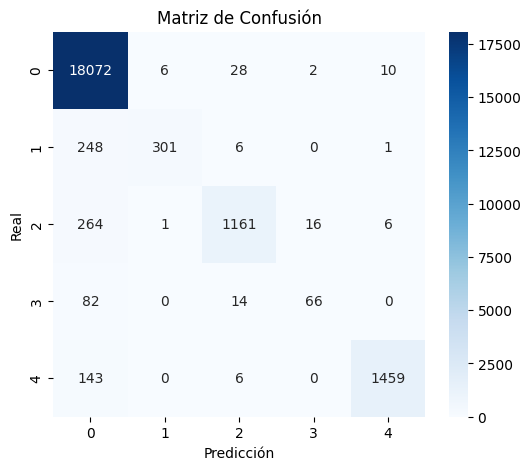

In [119]:
# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(xgb_results["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")    
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [121]:
print("Reporte de Clasificación:\n", xgb_results["classification_report"])

Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98     18118
         1.0       0.98      0.54      0.70       556
         2.0       0.96      0.80      0.87      1448
         3.0       0.79      0.41      0.54       162
         4.0       0.99      0.91      0.95      1608

    accuracy                           0.96     21892
   macro avg       0.93      0.73      0.81     21892
weighted avg       0.96      0.96      0.96     21892



### SVM

In [ ]:
# Libraies for SVM
from sklearn.svm import SVC

In [ ]:
# Set hyperparameters
kernel = 'linear'
C = 10
gamma = 'scale'
#TRY: kernel, parámetro C y el parámetro gamma

In [ ]:
linear_svm = SVC(kernel=kernel).fit(X_train, y_train)

### MLP

## Compración de resultados de todos los modelos

In [125]:
def cargar_resultados(directorio):
    archivos = [f for f in os.listdir(directorio) if f.endswith(".pkl")]
    resultados_totales = []
    for archivo in archivos:
        data = joblib.load(os.path.join(directorio, archivo))
        if isinstance(data, dict):
            resultados_totales.append(data["recall_test"])
    return pd.DataFrame(resultados_totales)

In [140]:
# Cargar todos los resultados
tabla_resultados = cargar_resultados('results/')
print("\nResumen de Resultados Completos:")
print(tabla_resultados)


Resumen de Resultados Completos:
          0
0  0.868556
1  0.577764
2  0.813500
3  0.670174
4  0.731074
